In [1]:
from experiment_common_code import ExperimentResult, plot_metrics_by_group, plot_confusion_matrix, show_plots, ExperimentResult
from common_constants import LANGUAGES, MODEL_NAMES
from icecream import ic

import torch as t

from typing import Literal

device: Literal["cuda", "cpu"] = "cuda" if t.cuda.is_available() else "cpu"

# Experiment 1

Load important variables

In [2]:
from experiment_1 import run_experiment_1

model_names: list[str] = MODEL_NAMES
languages: list[str] = LANGUAGES
probe_type: str = "lr"
num_layers: int | None = None

custom = True
if custom:
    model_names = ["olmo_model"]
    languages = ["en"]
    probe_type = "lr"
    print(f"Using custom configuration")

ic(custom, model_names, languages, probe_type)

ic| custom: True
    model_names: ['olmo_model']
    languages: ['en']
    probe_type: 'lr'


Using custom configuration


(True, ['olmo_model'], ['en'], 'lr')

Run experiment 1

In [3]:
limited_layers = False
if limited_layers:
    num_layers = 1

force_probe_creation: bool = False

save_results: bool = True

ic(limited_layers, force_probe_creation, save_results)

run_experiment_1(languages, "standard", "control", probe_type, model_names, force_probe_creation, num_layers=num_layers, save_results=save_results)

ic| limited_layers: False
    force_probe_creation: False
    save_results: True


Running experiment 1 instance. en, control, lr, olmo_model
Probing at layer 0
Creating probe
Probe saved to probes\olmo_model\lr_en_layer0_control.pkl
Probing at layer 1
Creating probe
Probe saved to probes\olmo_model\lr_en_layer1_control.pkl
Probing at layer 2
Creating probe
Probe saved to probes\olmo_model\lr_en_layer2_control.pkl
Probing at layer 3
Creating probe
Probe saved to probes\olmo_model\lr_en_layer3_control.pkl
Probing at layer 4
Creating probe
Probe saved to probes\olmo_model\lr_en_layer4_control.pkl
Probing at layer 5
Creating probe
Probe saved to probes\olmo_model\lr_en_layer5_control.pkl
Probing at layer 6
Creating probe
Probe saved to probes\olmo_model\lr_en_layer6_control.pkl
Probing at layer 7
Creating probe
Probe saved to probes\olmo_model\lr_en_layer7_control.pkl
Probing at layer 8
Creating probe
Probe saved to probes\olmo_model\lr_en_layer8_control.pkl
Probing at layer 9
Creating probe
Probe saved to probes\olmo_model\lr_en_layer9_control.pkl
Probing at layer 10
C

In [5]:
example_exp_result: ExperimentResult = ExperimentResult.get_from_file(
                        1, "en", "standard", probe_type, "olmo_model"
                    )
print(example_exp_result.metrics["test"].keys())

dict_keys(['cm', 'accuracy', 'per_class_precision', 'per_class_recall', 'per_class_f1', 'precision', 'recall', 'f1', 'marginal_accuracy', 'marginal_per_class_precision', 'marginal_per_class_recall', 'marginal_per_class_f1', 'marginal_precision', 'marginal_recall', 'marginal_f1'])


Make some plots

In [ ]:
# Save plots of all metrics
example_exp_result: ExperimentResult = ExperimentResult.get_from_file(
                        1, "en", "standard", probe_type, "olmo_model"
                    )
all_different_metrics: list[str] = list(example_exp_result.metrics["test"].keys())

save: bool = True

for metric in all_different_metrics:
    if metric == "cm":
        continue

    if "marginal" in metric:
        probing_tasks: list[str] = ["standard"]
    else:
        probing_tasks = ["standard", "control"]
    
    if "per_class" in metric:
        separate_chars_within_plot: list[str] = ["class"]
    else:
        separate_chars_within_plot = ["language", "probing_task"]
    
    print(f"Preparing plot for metric {metric}...")
    show_plots(model_names, 
               ["test", "train"], 
               languages, 
               probing_tasks, 
               probe_type, 
               1, 
               metric, 
               separate_chars_within_plot, 
               save=save, 
               filename=f"experiment1_{metric}" if save else "")

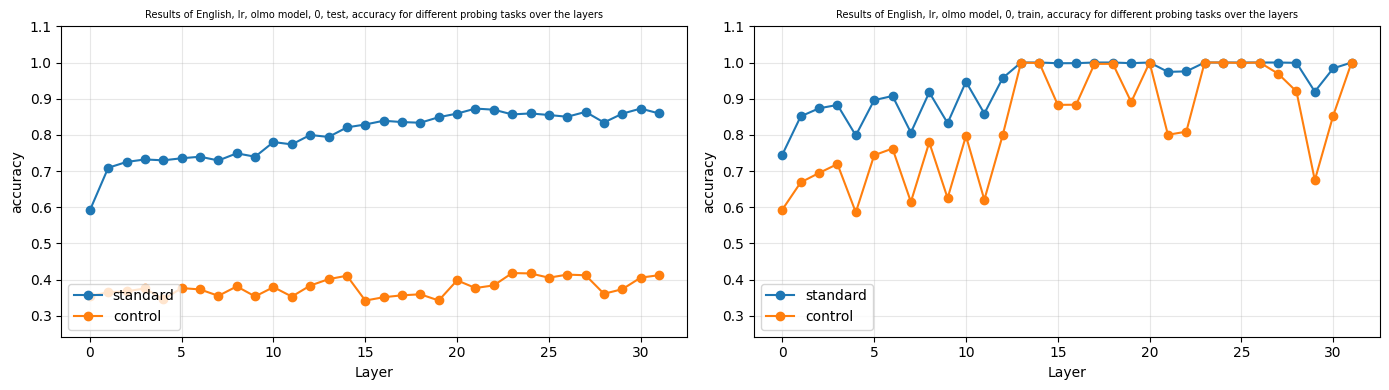

In [ ]:
# Get list of plots showing some arbitrary metric
metric = "accuracy"
show_plots(1, 
           model_names, 
           ["test", "train"], 
           languages, 
           ["standard", "control"], 
           metric=metric)

In [ ]:
# Get list of plots showing per class precision
show_plots(1, 
           model_names, 
           ["test"], 
           languages, 
           ["standard", "control"], 
           probe_type=probe_type, 
           metric="per_class_precision", 
           separate_chars_within_plot=["probing_task", "class"])
show_plots(1, 
           model_names, 
           ["test"], 
           languages, 
           ["standard"], 
           probe_type=probe_type, 
           metric="marginal_per_class_precision", 
           separate_chars_within_plot=["probing_task", "class"])

In [ ]:
# Get list of plots showing accuracy
show_plots(1, 
           model_names, 
           ["test", "train"], 
           languages, 
           ["standard", "control"], 
           probe_type=probe_type, 
           metric="accuracy", 
           separate_chars_within_plot=["probing_task", "class"])

In [ ]:
# Get list of plots showing marginal recall
show_plots(1, 
           model_names, 
           ["test", "train"], 
           languages, 
           ["standard"], 
           probe_type=probe_type, 
           metric="marginal_recall", 
           separate_chars_within_plot=["probing_task", "class"])


In [ ]:
# for model_name in model_names:
#     for split in ["test", "train"]:
#         for language in languages:
#             for probing_task in probing_tasks:
#                 exp_result: ExperimentResult = ExperimentResult.get_from_file(
#                     1, language, probing_task, probe_type, model_name
#                 )

#                 for layer_num in range(exp_result.get_num_layers()):
#                     plot_confusion_matrix(exp_result, split, layer_num)

for probing_task in ["standard", "control"]:
    exp_result: ExperimentResult = ExperimentResult.get_from_file(1, "en", probing_task, probe_type, "olmo_model")

    for layer_num in range(exp_result.get_num_layers()):
        plot_confusion_matrix(exp_result, "test", layer_num)

# Experiment 2

Load important variables

In [ ]:
from experiment_2 import run_experiment_2, get_multiple_language_merged_strings, get_language_pairs

model_names: list[str] = MODEL_NAMES
language_pairs: list[tuple[str, str]] = get_language_pairs(LANGUAGES)
num_refits = 10
iterations_per_refit = 10
probe_type: str = "lr"

custom = False
if custom:
    model_names = ["olmo_model"]
    language_pairs = [("en", "es")]
    probe_type = "lr"
    print(f"Using custom configuration")

language_pairs_as_strings: list[str] = get_multiple_language_merged_strings(language_pairs)

ic(custom, model_names, language_pairs, num_refits, iterations_per_refit, language_pairs_as_strings, probe_type)

ic| custom: False
    model_names: ['olmo_model', 'tiny_aya_global']
    language_pairs: [('en', 'es'), ('es', 'en')]
    num_refits: 10
    iterations_per_refit: 50
    language_pairs_as_strings: ['en→es', 'es→en']
    probe_type: 'lr'

(False,
 ['olmo_model', 'tiny_aya_global'],
 [('en', 'es'), ('es', 'en')],
 10,
 50,
 ['en→es', 'es→en'],
 'lr')

Run experiment 2

In [6]:
num_layers: int | None = None

limited_layers = False
if limited_layers:
    num_layers = 2

force_probe_creation: bool = False

save_results: bool = True

ic(limited_layers, num_layers, force_probe_creation, save_results)

run_experiment_2(language_pairs, 
                 "standard", 
                 "control", 
                 probe_type, 
                 model_names, 
                 num_refits,
                 iterations_per_refit,
                 force_probe_creation, 
                 num_layers=num_layers, 
                 save_results=save_results,
                 )

ic| limited_layers: False
    num_layers: None
    force_probe_creation: False
    save_results: True


Running experiment 2 instance. en→es, control, lr, olmo_model
Model not loaded. Getting the number of layers from ./data/activations/olmo_model/n_layers.txt
Probe already exists. Loading from file...
Probe loaded from probes\olmo_model\lr_en_layer0_control.pkl
Probe already exists. Loading from file...
Probe loaded from probes\olmo_model\lr_en_layer1_control.pkl
Probe already exists. Loading from file...
Probe loaded from probes\olmo_model\lr_en_layer2_control.pkl
Probe already exists. Loading from file...
Probe loaded from probes\olmo_model\lr_en_layer3_control.pkl
Probe already exists. Loading from file...
Probe loaded from probes\olmo_model\lr_en_layer4_control.pkl
Probe already exists. Loading from file...
Probe loaded from probes\olmo_model\lr_en_layer5_control.pkl
Probe already exists. Loading from file...
Probe loaded from probes\olmo_model\lr_en_layer6_control.pkl
Probe already exists. Loading from file...
Probe loaded from probes\olmo_model\lr_en_layer7_control.pkl
Probe alrea

Make some plots

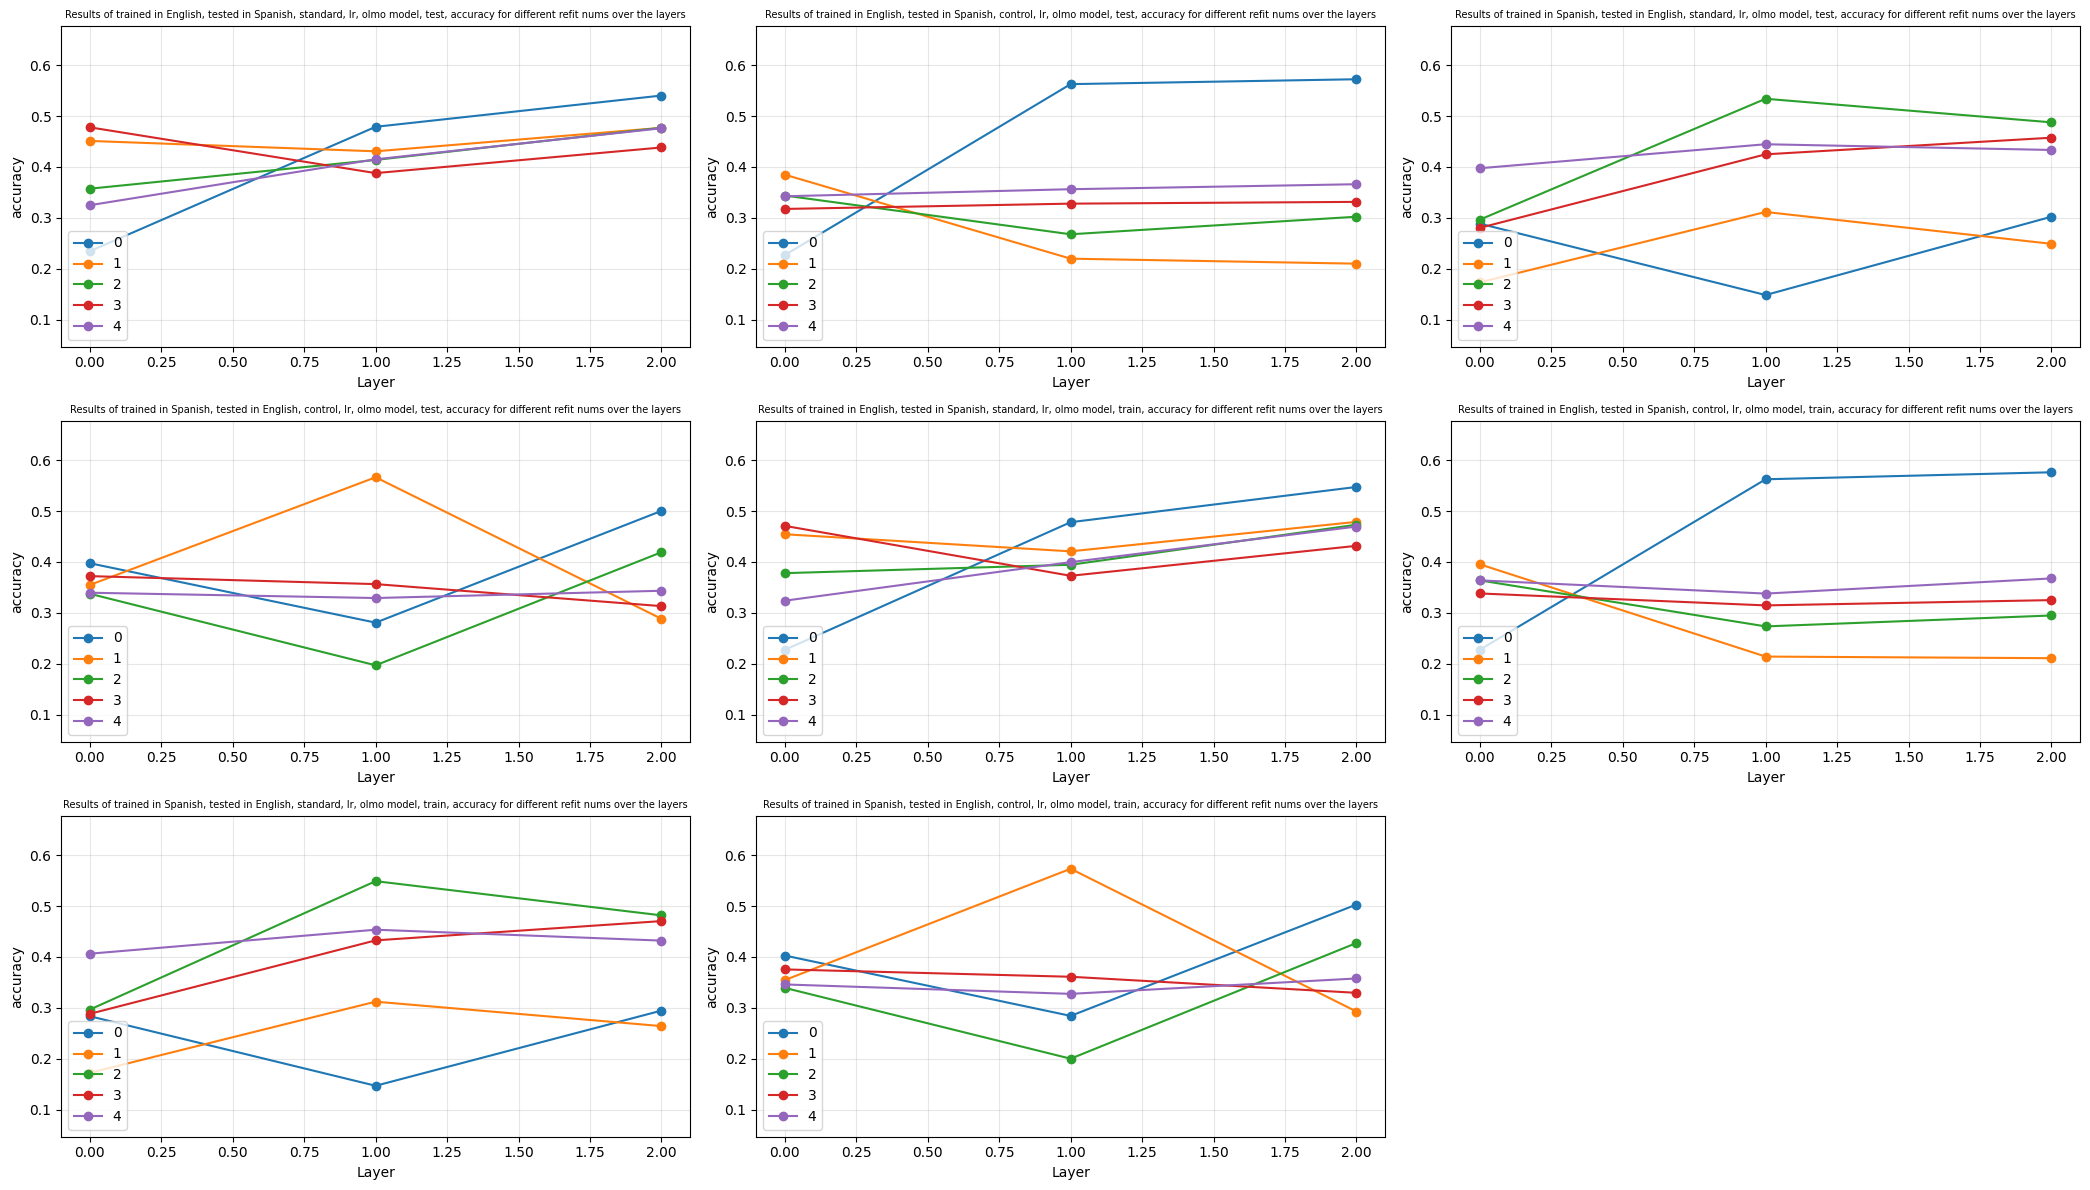

In [ ]:
# Get list of plots showing accuracy
show_plots(2, 
           model_names, 
           ["test", "train"],
           language_pairs_as_strings, 
           ["standard", "control"], 
           list(range(num_refits)), 
           metric="accuracy",
           separate_chars_within_plot=["refit_num"]
           )

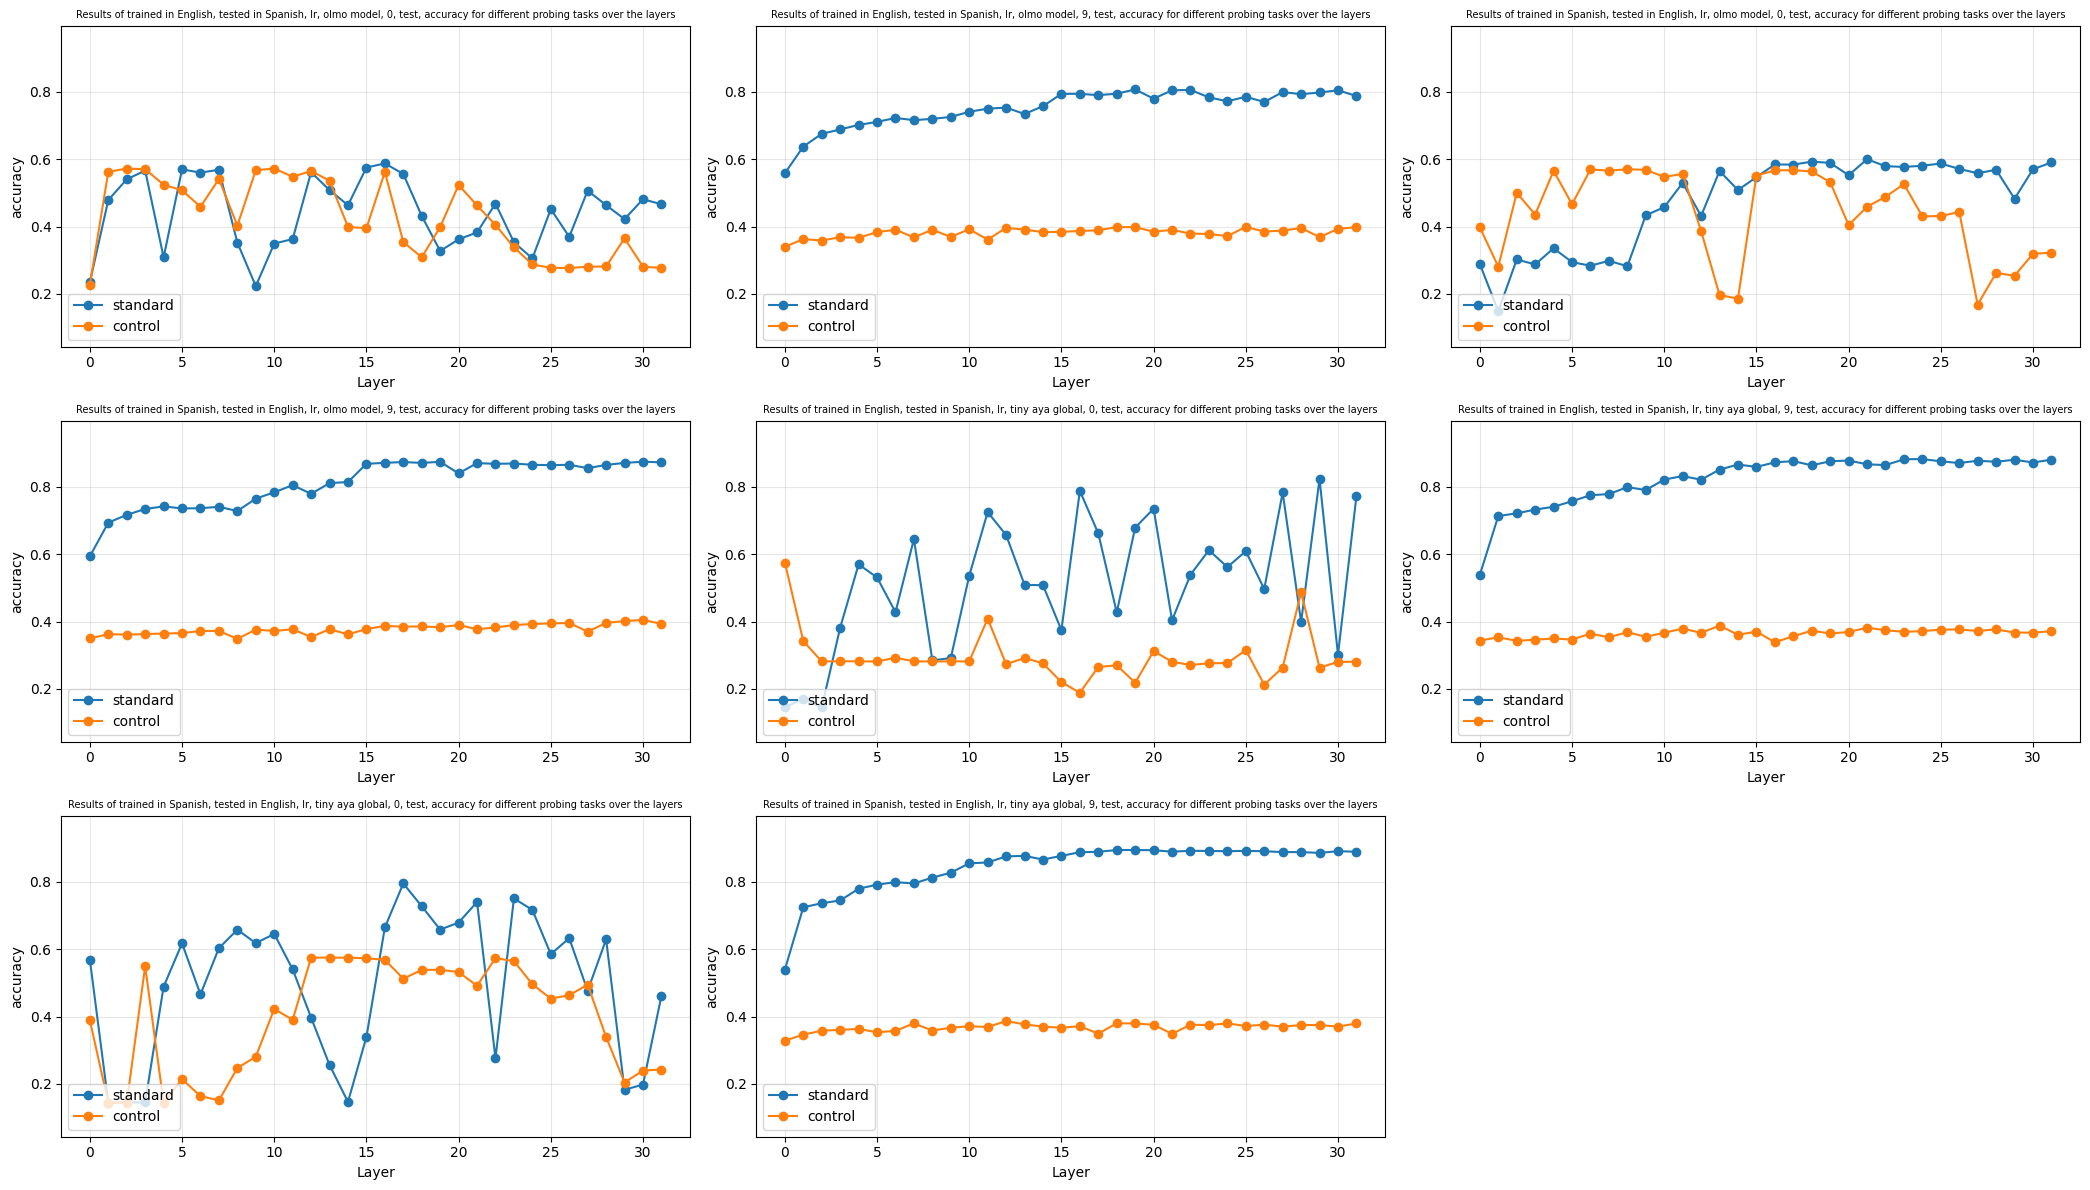

In [8]:
show_plots(2, 
           model_names, 
           ["test"],
           language_pairs_as_strings, 
           ["standard", "control"], 
           [0, 9], 
           metric="accuracy",
           separate_chars_within_plot=["probing_task"]
           )

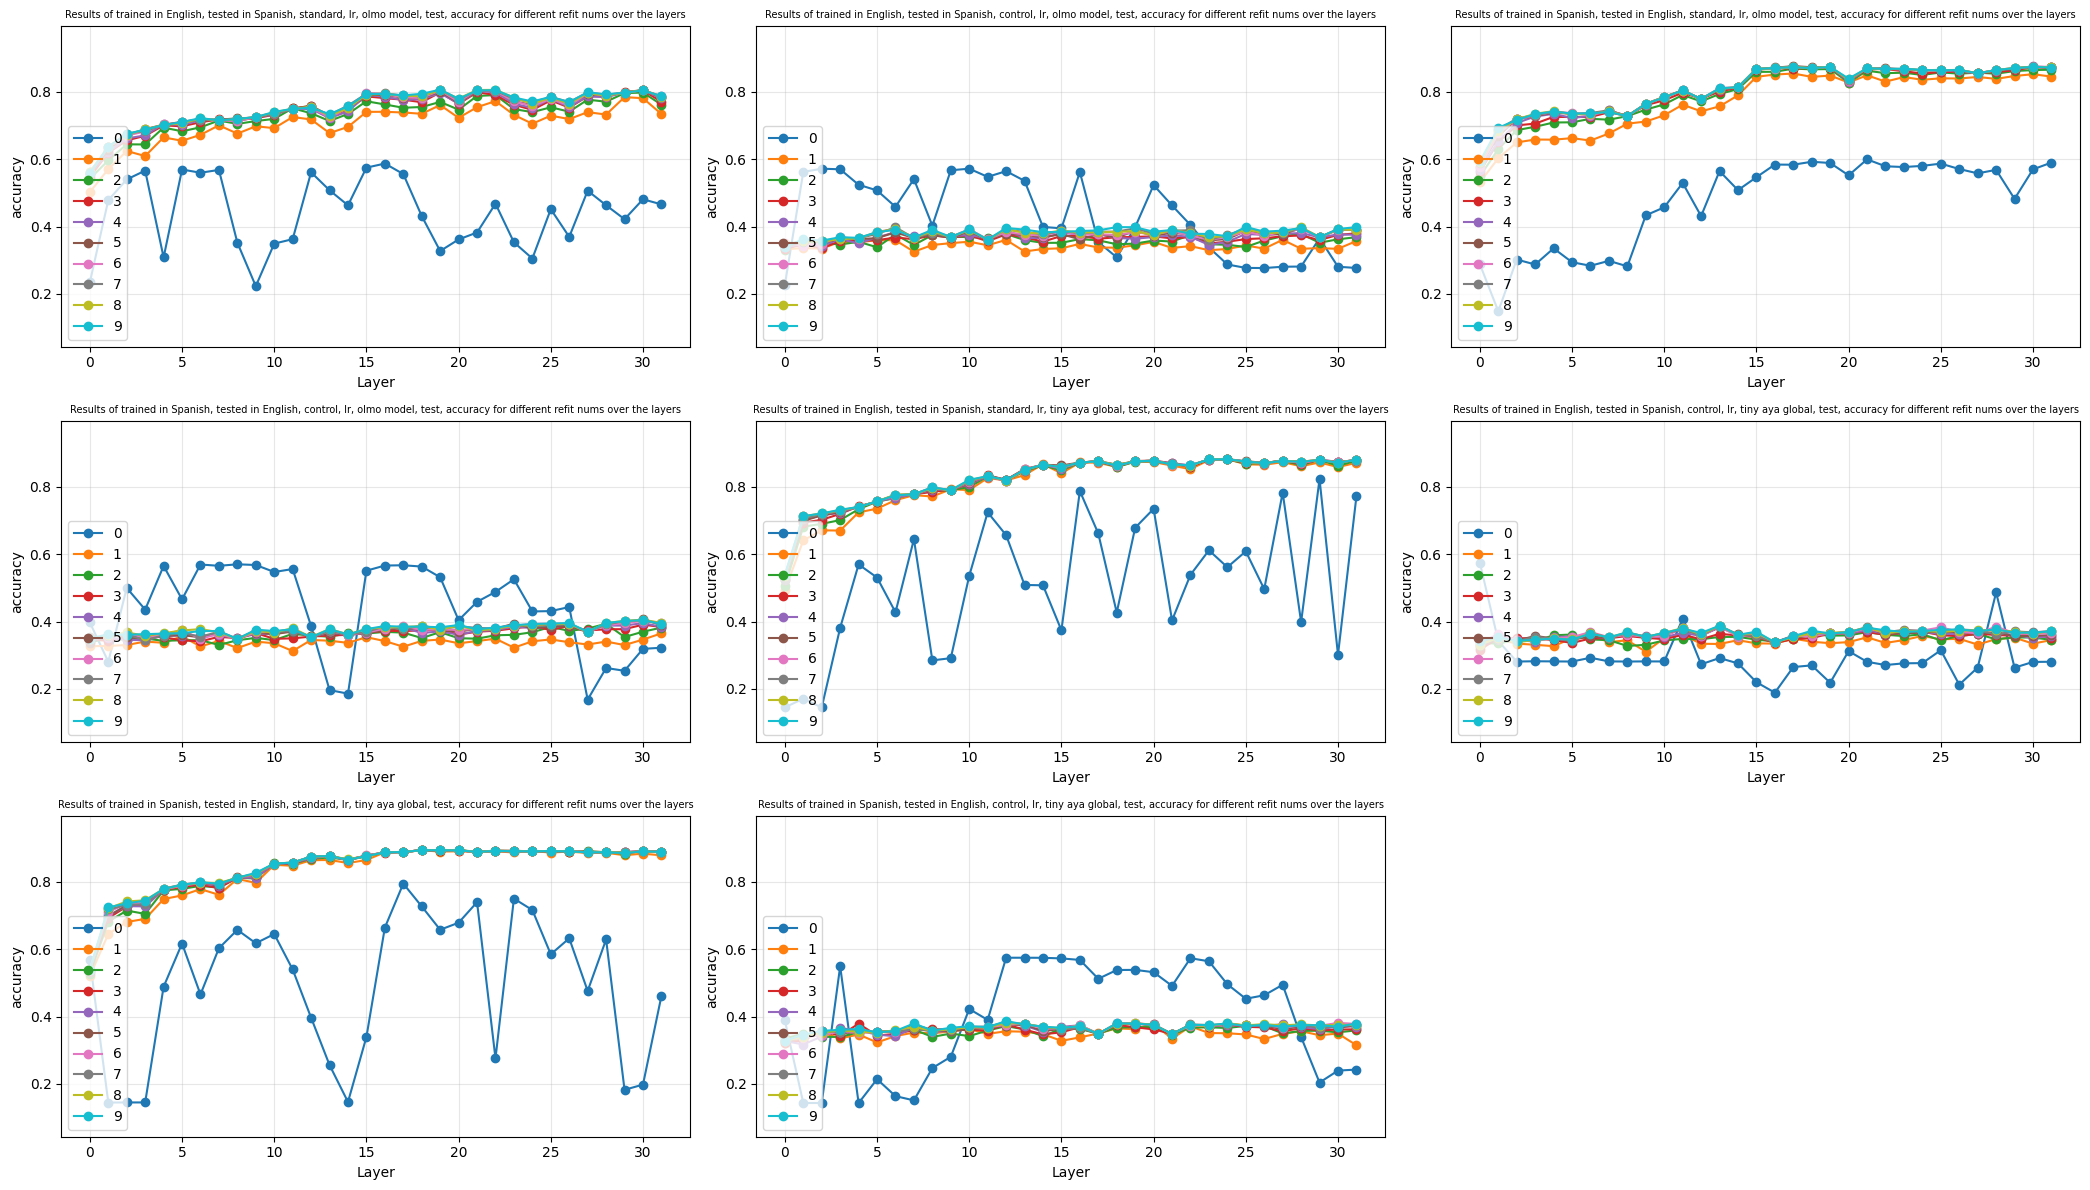

In [9]:
show_plots(2, 
           model_names, 
           ["test"],
           language_pairs_as_strings, 
           ["standard", "control"], 
           list(range(num_refits)), 
           metric="accuracy",
           separate_chars_within_plot=["refit_num"]
           )

In [ ]:
# for model_name in model_names:
#     for split in ["test", "train"]:
#         for language in languages:
#             for probing_task in probing_tasks:
#                 exp_result: ExperimentResult = ExperimentResult.get_from_file(
#                     2, language, probing_task, probe_type, model_name
#                 )

#                 for layer_num in range(exp_result.get_num_layers()):
#                     plot_confusion_matrix(exp_result, split, layer_num)

for probing_task in ["standard", "control"]:
    exp_result: ExperimentResult = ExperimentResult.get_from_file(2, "en", probing_task, probe_type, "olmo_model")

    for layer_num in range(exp_result.get_num_layers()):
        plot_confusion_matrix(exp_result, "test", layer_num)